In [14]:
!pip install -q torch matplotlib scikit-learn

In [ ]:
import torch
import numpy as np

In [2]:
torch.__version__

'2.6.0'

## Linear Regression Formula to estimate

### y = 4.5 * X + 2.2

## Generate synthetic data

### y = 4.5 * X + 2.2 + noise

In [6]:
# Set the seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

In [27]:
N_SAMPLES = 100
X = np.arange(N_SAMPLES)
noise = np.random.normal(0, 40, N_SAMPLES)
y = 4.5 * X + 2.2 + noise

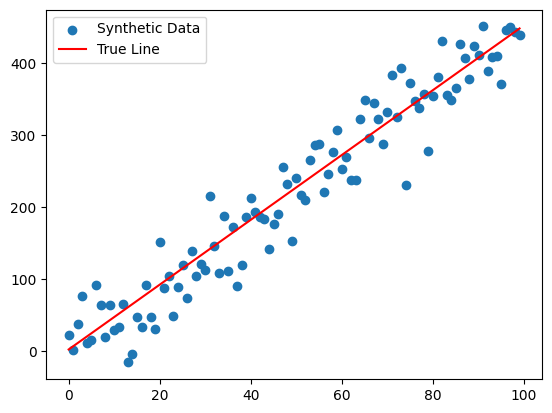

In [8]:
# Scatter plot
import matplotlib.pyplot as plt

plt.scatter(X, y, label="Synthetic Data")
plt.plot(X, 4.5 * X + 2.2, color='red', label="True Line")
plt.legend()
plt.show()

In [28]:
# make X and y 2D
X = X.reshape(-1, 1)
y = y.reshape(-1, 1)

In [29]:
X.shape, y.shape

((100, 1), (100, 1))

## Split the data into training and testing sets

In [15]:
from sklearn.model_selection import train_test_split

In [30]:
# Split the data
TRAIN_SIZE = 0.8
N_TRAIN = int(TRAIN_SIZE * N_SAMPLES)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=TRAIN_SIZE)

In [31]:
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")

Training set size: 80
Test set size: 20


## Standardize the data

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
X_scaler = StandardScaler().fit(X_train)
y_scaler = StandardScaler().fit(y_train)

In [ ]:
X_train = X_scaler.transform(X_train)
y_train = y_scaler.transform(y_train)
X_test = X_scaler.transform(X_test)
y_test = y_scaler.transform(y_test)

In [24]:
print(f"X_train mean: {X_train.mean():.2f}, std: {X_train.std():.2f}")
print(f"y_train mean: {y_train.mean():.2f}, std: {y_train.std():.2f}")

X_train mean: -0.00, std: 1.00
y_train mean: -0.00, std: 1.00


## Linear layers of pytorch

In [47]:
import torch.nn as nn

In [38]:
INPUT_DIM = X_train.shape[1]
OUTPUT_DIM = 1
x = torch.randn(N_SAMPLES, INPUT_DIM)
print(x.shape)
print(x[:5])

torch.Size([100, 1])
tensor([[ 0.1954],
        [-1.3350],
        [ 0.3945],
        [ 1.7060],
        [-0.7939]])


In [48]:
m = nn.Linear(INPUT_DIM, OUTPUT_DIM)
print(m)

Linear(in_features=1, out_features=1, bias=True)


In [49]:
m.weight

Parameter containing:
tensor([[-0.8309]], requires_grad=True)

In [50]:
m.bias

Parameter containing:
tensor([-0.5462], requires_grad=True)

In [51]:
# Forward pass
z = m(x)
print(z.shape)
print(z.detach().numpy()[:5])

torch.Size([100, 1])
[[-0.7085493 ]
 [ 0.5631336 ]
 [-0.8740243 ]
 [-1.9638298 ]
 [ 0.11351192]]


## Model

In [52]:
class LinearRegression(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(LinearRegression, self).__init__()
        self.fc = nn.Linear(input_dim, output_dim)

    def forward(self, x):
        x = self.fc(x)
        return x

In [53]:
model = LinearRegression(INPUT_DIM, OUTPUT_DIM)
model

LinearRegression(
  (fc): Linear(in_features=1, out_features=1, bias=True)
)

## Loss

In [55]:
loss_fn = nn.MSELoss()
y_true = torch.Tensor([0., 0., 0., 1.0, 1.0])
y_pred = torch.Tensor([1., 0., 1., 0.0, 1.0])
loss_fn(y_true, y_pred)

tensor(0.6000)

## Main Training Loop

In [30]:
N_LOOPS = 1000
LEARNING_RATE = 0.05

In [31]:
# Training loop
for epoch in range(N_LOOPS):
    # Forward pass
    y_pred = np.dot(X_train, W) + b

    # Compute the mse loss
    error = y_pred - y_train
    loss = np.mean(error ** 2)

    # Compute the gradients
    W_grad = np.dot(X_train.T, error) / N_TRAIN
    b_grad = np.sum(error) / N_TRAIN

    # Update the weights
    W -= LEARNING_RATE * W_grad
    b -= LEARNING_RATE * b_grad

    if epoch % 10 == 0:
        print(f"Epoch: {epoch}, Loss: {loss:.4f}")

Epoch: 0, Loss: 0.1210
Epoch: 10, Loss: 0.0932
Epoch: 20, Loss: 0.0832
Epoch: 30, Loss: 0.0797
Epoch: 40, Loss: 0.0784
Epoch: 50, Loss: 0.0779
Epoch: 60, Loss: 0.0778
Epoch: 70, Loss: 0.0777
Epoch: 80, Loss: 0.0777
Epoch: 90, Loss: 0.0777
Epoch: 100, Loss: 0.0777
Epoch: 110, Loss: 0.0777
Epoch: 120, Loss: 0.0777
Epoch: 130, Loss: 0.0777
Epoch: 140, Loss: 0.0777
Epoch: 150, Loss: 0.0777
Epoch: 160, Loss: 0.0777
Epoch: 170, Loss: 0.0777
Epoch: 180, Loss: 0.0777
Epoch: 190, Loss: 0.0777
Epoch: 200, Loss: 0.0777
Epoch: 210, Loss: 0.0777
Epoch: 220, Loss: 0.0777
Epoch: 230, Loss: 0.0777
Epoch: 240, Loss: 0.0777
Epoch: 250, Loss: 0.0777
Epoch: 260, Loss: 0.0777
Epoch: 270, Loss: 0.0777
Epoch: 280, Loss: 0.0777
Epoch: 290, Loss: 0.0777
Epoch: 300, Loss: 0.0777
Epoch: 310, Loss: 0.0777
Epoch: 320, Loss: 0.0777
Epoch: 330, Loss: 0.0777
Epoch: 340, Loss: 0.0777
Epoch: 350, Loss: 0.0777
Epoch: 360, Loss: 0.0777
Epoch: 370, Loss: 0.0777
Epoch: 380, Loss: 0.0777
Epoch: 390, Loss: 0.0777
Epoch: 400,

## Evaluation

In [32]:
W, b

(array([[0.9603817]]), array([1.11716192e-16]))

In [34]:
pred_train = W * X_train + b
pred_test = W * X_test + b

In [35]:
# Train and test mse
train_mse = np.mean((pred_train - y_train) ** 2)
test_mse = np.mean((pred_test - y_test) ** 2)

In [38]:
print (f"train mse: {train_mse:.2f}, test mse: {test_mse:.2f}")

train mse: 0.08, test mse: 0.04


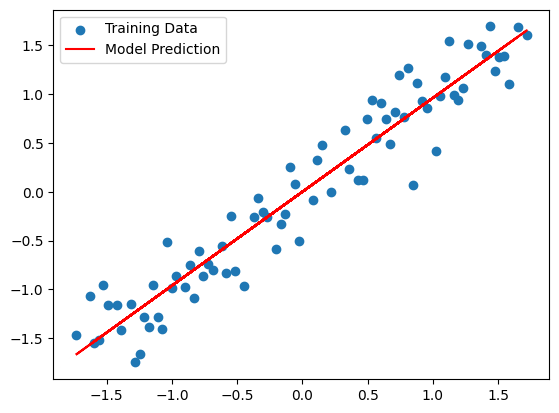

In [39]:
# Plot training data
plt.scatter(X_train, y_train, label="Training Data")
plt.plot(X_train, pred_train, color='red', label="Model Prediction")
plt.legend()
plt.show()

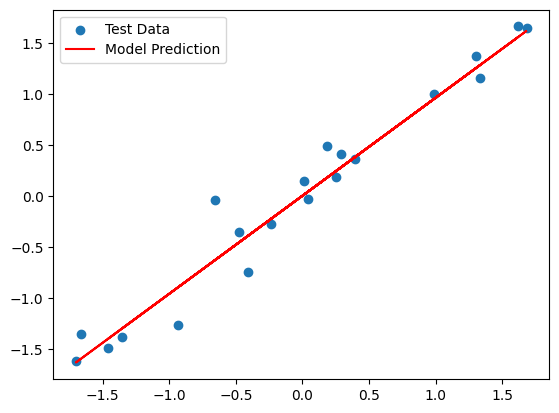

In [40]:
# Plot test data
plt.scatter(X_test, y_test, label="Test Data")
plt.plot(X_test, pred_test, color='red', label="Model Prediction")
plt.legend()
plt.show()

## Unstandardize the data

In [45]:
W_unstd = W * (y_std / X_std)
b_unstd = b * y_std + y_mean - np.sum(W_unstd * X_mean)
print(f"Weight: {W_unstd[0][0]:.2f}, Bias + Noise: {b_unstd[0]:.2f}")

Weight: 4.55, Bias + Noise: -5.02
